In [11]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.cm as cm

In [ ]:
# Importa las capas 
gdf_regional = gpd.read_file("../data/rec_2024_2025/results/capas_regionales/wp2_output_demanda_electrica_regional.gpkg")
gdf_comunal = gpd.read_file("../data/rec_2024_2025/results/capas_comunales/wp2_output_demanda_electrica_comunal.gpkg")

In [10]:
# --- 0. CONFIGURACIÓN INICIAL ---
sectores = ['R', 'C', 'P', 'I', 'T']
nombres_sectores = ['Residencial', 'Comercial', 'Público', 'Industrial', 'Transporte']
cols_sectores = [f'demanda_{s}_GWh' for s in sectores]

Generando mapa Comunal RM (2025) con escala logarítmica...


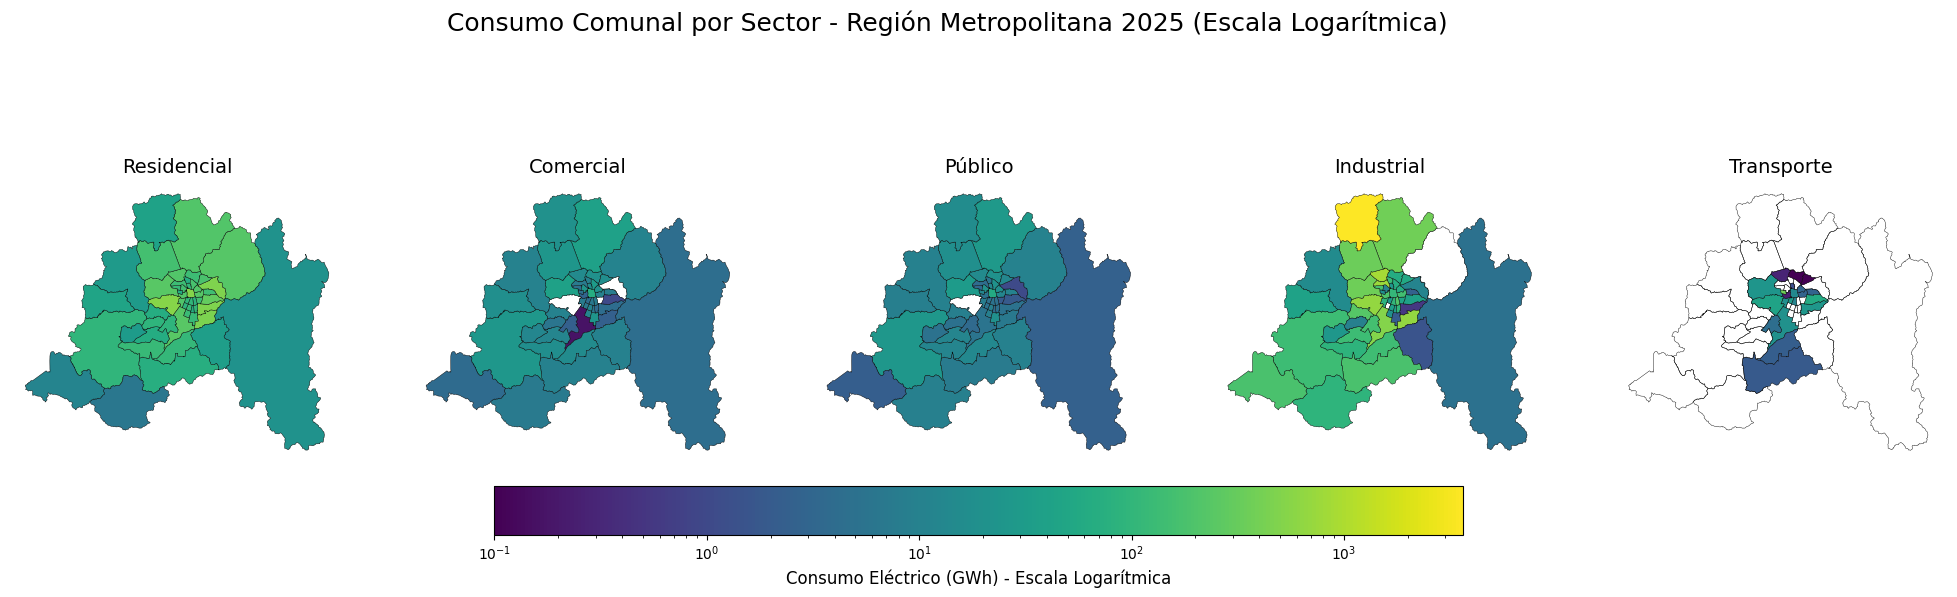

In [22]:
# =====================================================================
# GRÁFICO: COMUNAS DE LA REGIÓN METROPOLITANA (2025) - ESCALA LOGARÍTMICA
# =====================================================================
print("Generando mapa Comunal RM (2025) con escala logarítmica...")

# Filtrar RM
rm_2025 = gdf_comunal[
    (gdf_comunal['año'] == 2025) & 
    (gdf_comunal['region_x'].str.contains('METROPOLITANA', case=False, na=False))
]

# 1. Definir el límite máximo para la RM
vmax_rm = rm_2025[cols_sectores].max().max()

# 2. Definir un mínimo seguro mayor a 0 (LogNorm explota con valores <= 0)
vmin_seguro = 0.1 

# 3. Crear el objeto de normalización logarítmica
norm_log_rm = mcolors.LogNorm(vmin=vmin_seguro, vmax=vmax_rm)

fig3, axes3 = plt.subplots(1, 5, figsize=(25, 6)) # Un poco más bajo (6) porque la RM es más ancha que larga

for ax, sector, nombre in zip(axes3, cols_sectores, nombres_sectores):
    rm_2025.plot(
        column=sector, 
        ax=ax, 
        cmap='viridis', 
        norm=norm_log_rm,   # <--- Usamos LogNorm en lugar de vmin/vmax directos
        edgecolor='black', 
        linewidth=0.3       # Aquí sí activamos los bordes
    )
    ax.set_title(f"{nombre}", fontsize=14)
    ax.set_axis_off()

# 4. Crear la barra de color usando la misma normalización logarítmica
sm_rm = cm.ScalarMappable(cmap='viridis', norm=norm_log_rm)
sm_rm.set_array([])
cbar3 = fig3.colorbar(sm_rm, ax=axes3.ravel().tolist(), shrink=0.5, orientation='horizontal', pad=0.05)
cbar3.set_label('Consumo Eléctrico (GWh) - Escala Logarítmica', fontsize=12)

plt.suptitle("Consumo Comunal por Sector - Región Metropolitana 2025 (Escala Logarítmica)", fontsize=18, y=1.02)
plt.show()